# Phase 5: Model Training and Comparison

## Objective

The goal of this notebook is to train machine learning models that predict lap time for the 2025 Monaco Grand Prix.

The target variable is:

`LapTimeSeconds`

We will train and compare multiple regression models:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The models will be evaluated using:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- R²: Coefficient of Determination
- MAPE: Mean Absolute Percentage Error

For this project, MAE is the most important metric because it tells us how many seconds the prediction is off by on average.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
METRICS_DIR = Path("../outputs/metrics")
FIGURES_DIR = Path("../outputs/figures")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ml_dataset_path = PROCESSED_DATA_DIR / "2025_monaco_ml_dataset.csv"

In [3]:
df = pd.read_csv(ml_dataset_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1401, 20)


,Driver,Team,Compound,LapNumber,TyreLife,TyreLifeSquared,Stint,Position,TrackStatus,IsPitLap,IsGreenFlag,RaceProgress,StintLength,StintProgress,DriverMedianPace,TeamMedianPace,PreviousLapTime,Rolling3LapAvg,Rolling5LapAvg,LapTimeSeconds
0,ALB,Williams,MEDIUM,2.0,6.0,36.0,1.0,10.0,16,0,0,0.025641,32.0,0.06250,77.086,77.075,91.479,91.479000,91.479000,112.152
1,ALB,Williams,MEDIUM,3.0,7.0,49.0,1.0,10.0,6,0,0,0.038462,32.0,0.09375,77.086,77.075,112.152,101.815500,101.815500,108.346
2,ALB,Williams,MEDIUM,4.0,8.0,64.0,1.0,10.0,671,0,0,0.051282,32.0,0.12500,77.086,77.075,108.346,103.992333,103.992333,96.006
3,ALB,Williams,MEDIUM,5.0,9.0,81.0,1.0,10.0,1,0,1,0.064103,32.0,0.15625,77.086,77.075,96.006,105.501333,101.995750,80.465
4,ALB,Williams,MEDIUM,6.0,10.0,100.0,1.0,10.0,1,0,1,0.076923,32.0,0.18750,77.086,77.075,80.465,94.939000,97.689600,81.426


In [4]:
df.columns.tolist()

['Driver',
 'Team',
 'Compound',
 'LapNumber',
 'TyreLife',
 'TyreLifeSquared',
 'Stint',
 'Position',
 'TrackStatus',
 'IsPitLap',
 'IsGreenFlag',
 'RaceProgress',
 'StintLength',
 'StintProgress',
 'DriverMedianPace',
 'TeamMedianPace',
 'PreviousLapTime',
 'Rolling3LapAvg',
 'Rolling5LapAvg',
 'LapTimeSeconds']

## Define Features and Target

The model will use race context, tyre information, driver/team information, previous lap pace, and rolling average pace to predict lap time.

The target variable is `LapTimeSeconds`.

In [5]:
target = "LapTimeSeconds"

categorical_features = [
    "Driver",
    "Team",
    "Compound"
]

numeric_features = [
    "LapNumber",
    "TyreLife",
    "TyreLifeSquared",
    "Stint",
    "Position",
    "TrackStatus",
    "IsPitLap",
    "IsGreenFlag",
    "RaceProgress",
    "StintLength",
    "StintProgress",
    "DriverMedianPace",
    "TeamMedianPace",
    "PreviousLapTime",
    "Rolling3LapAvg",
    "Rolling5LapAvg"
]

feature_columns = categorical_features + numeric_features

X = df[feature_columns].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1401, 19)
Target shape: (1401,)


In [6]:
y.describe()

count    1401.000000
mean       79.042440
std         6.369163
min        73.221000
25%        76.016000
50%        77.611000
75%        79.313000
max       112.404000
Name: LapTimeSeconds, dtype: float64

## Train/Test Split

For the first version of this project, we will use a standard train/test split.

Later, when the project expands to multiple races, we can make the validation more realistic by training on some races and testing on an unseen race.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1120, 19)
X_test shape: (281, 19)
y_train shape: (1120,)
y_test shape: (281,)


## Preprocessing Pipeline

Categorical features such as driver, team, and tyre compound need to be converted into numeric columns using one-hot encoding.

Numeric features will be scaled for the Linear Regression model. Tree-based models do not require scaling, but using a consistent preprocessing pipeline keeps the workflow cleaner.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

## Train Models

We will compare three models:

1. Linear Regression — simple baseline model
2. Random Forest Regressor — non-linear tree-based model
3. Gradient Boosting Regressor — boosted tree model

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [10]:
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """
    Calculates MAPE safely by avoiding division by zero.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    nonzero_mask = y_true != 0
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100


def evaluate_model(model_name, pipeline, X_test, y_test):
    """
    Evaluates a trained model and returns common regression metrics.
    """
    predictions = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error_safe(y_test, predictions)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [11]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    metrics = evaluate_model(model_name, pipeline, X_test, y_test)
    results.append(metrics)
    trained_pipelines[model_name] = pipeline
    
    print(f"{model_name} complete.")
    print(metrics)
    print("-" * 50)

model_comparison = pd.DataFrame(results).sort_values("MAE")
model_comparison

Training Linear Regression...
Linear Regression complete.
{'Model': 'Linear Regression', 'MAE': 2.259937362313413, 'RMSE': np.float64(3.8154282362236605), 'R2': 0.5749527135686082, 'MAPE': np.float64(2.7236981547980865)}
--------------------------------------------------
Training Random Forest...
Random Forest complete.
{'Model': 'Random Forest', 'MAE': 0.6236618505338088, 'RMSE': np.float64(0.9525505976031655), 'R2': 0.9735072661339956, 'MAPE': np.float64(0.7864915958382134)}
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting complete.
{'Model': 'Gradient Boosting', 'MAE': 0.6735388039057232, 'RMSE': np.float64(1.0338008505070706), 'R2': 0.9687949818596258, 'MAPE': np.float64(0.8444079843548459)}
--------------------------------------------------


,Model,MAE,RMSE,R2,MAPE
1,Random Forest,0.623662,0.952551,0.973507,0.786492
2,Gradient Boosting,0.673539,1.033801,0.968795,0.844408
0,Linear Regression,2.259937,3.815428,0.574953,2.723698


In [12]:
model_comparison_path = METRICS_DIR / "monaco_2025_model_comparison.csv"

model_comparison.to_csv(model_comparison_path, index=False)

print("Saved model comparison:")
print(model_comparison_path)

Saved model comparison:
../outputs/metrics/monaco_2025_model_comparison.csv


## Select Best Model

The best model is selected based on the lowest MAE.

MAE tells us how many seconds the model is off by on average.

In [13]:
best_model_name = model_comparison.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model:", best_model_name)
print(model_comparison.iloc[0])

Best model: Random Forest
Model    Random Forest
MAE           0.623662
RMSE          0.952551
R2            0.973507
MAPE          0.786492
Name: 1, dtype: object


In [14]:
best_model_path = MODELS_DIR / "monaco_2025_lap_time_model.pkl"
best_pipeline_path = MODELS_DIR / "monaco_2025_model_pipeline.pkl"

joblib.dump(best_pipeline, best_model_path)
joblib.dump(best_pipeline, best_pipeline_path)

print("Saved best model:")
print(best_model_path)
print(best_pipeline_path)

Saved best model:
../models/monaco_2025_lap_time_model.pkl
../models/monaco_2025_model_pipeline.pkl


## Actual vs Predicted Lap Times

This chart compares the model's predicted lap times against actual lap times.

A perfect model would have all points close to the diagonal line.

In [15]:
y_pred = best_pipeline.predict(X_test)

prediction_results = X_test.copy()
prediction_results["ActualLapTimeSeconds"] = y_test.values
prediction_results["PredictedLapTimeSeconds"] = y_pred
prediction_results["PredictionErrorSeconds"] = (
    prediction_results["ActualLapTimeSeconds"] - prediction_results["PredictedLapTimeSeconds"]
)

prediction_results.head()

,Driver,Team,Compound,LapNumber,TyreLife,TyreLifeSquared,Stint,Position,TrackStatus,IsPitLap,...,StintLength,StintProgress,DriverMedianPace,TeamMedianPace,PreviousLapTime,Rolling3LapAvg,Rolling5LapAvg,ActualLapTimeSeconds,PredictedLapTimeSeconds,PredictionErrorSeconds
1092,RUS,Mercedes,HARD,70.0,2.0,4.0,3.0,11.0,1,0,...,8.0,0.250000,78.479,78.8650,78.119,80.893000,78.1754,74.303,75.351320,-1.048320
948,PIA,McLaren,MEDIUM,3.0,3.0,9.0,1.0,3.0,6,0,...,20.0,0.150000,75.113,75.1900,106.466,96.303500,96.3035,108.176,109.061520,-0.885520
49,ALB,Williams,HARD,51.0,11.0,121.0,3.0,11.0,1,0,...,36.0,0.305556,77.086,77.0750,79.166,79.197667,79.2196,79.828,80.048200,-0.220200
1257,TSU,Red Bull Racing,HARD,10.0,9.0,81.0,2.0,17.0,2,0,...,72.0,0.125000,78.811,76.6390,79.611,80.706333,79.8126,81.823,81.018517,0.804483
706,LAW,Racing Bulls,HARD,67.0,28.0,784.0,3.0,8.0,1,0,...,37.0,0.729730,76.824,77.0135,76.955,77.756333,77.5488,77.409,77.052933,0.356067


In [16]:
prediction_results_path = PROCESSED_DATA_DIR / "2025_monaco_prediction_results.csv"

prediction_results.to_csv(prediction_results_path, index=False)

print("Saved prediction results:")
print(prediction_results_path)

Saved prediction results:
../data/processed/2025_monaco_prediction_results.csv


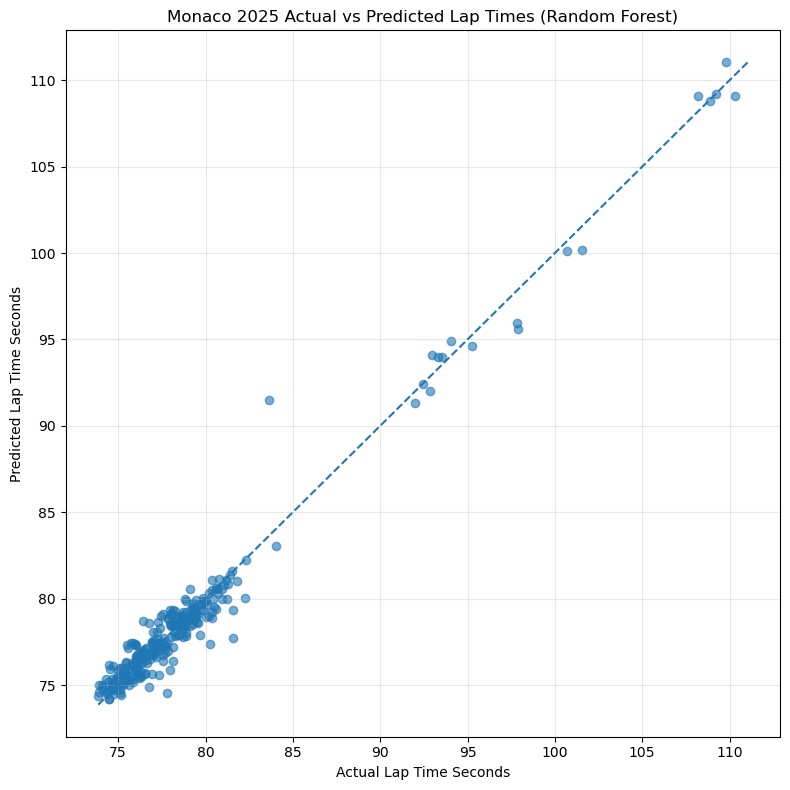

In [17]:
plt.figure(figsize=(8, 8))

plt.scatter(
    prediction_results["ActualLapTimeSeconds"],
    prediction_results["PredictedLapTimeSeconds"],
    alpha=0.6
)

min_val = min(
    prediction_results["ActualLapTimeSeconds"].min(),
    prediction_results["PredictedLapTimeSeconds"].min()
)

max_val = max(
    prediction_results["ActualLapTimeSeconds"].max(),
    prediction_results["PredictedLapTimeSeconds"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Monaco 2025 Actual vs Predicted Lap Times ({best_model_name})")
plt.xlabel("Actual Lap Time Seconds")
plt.ylabel("Predicted Lap Time Seconds")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "monaco_2025_actual_vs_predicted.png", dpi=300)
plt.show()

## Prediction Error Analysis

Prediction error is calculated as:

`ActualLapTimeSeconds - PredictedLapTimeSeconds`

Positive error means the actual lap was slower than predicted.

Negative error means the actual lap was faster than predicted.

In [18]:
prediction_results["PredictionErrorSeconds"].describe()

count    281.000000
mean      -0.020333
std        0.954033
min       -7.872107
25%       -0.453173
50%       -0.016520
75%        0.422950
max        3.854947
Name: PredictionErrorSeconds, dtype: float64

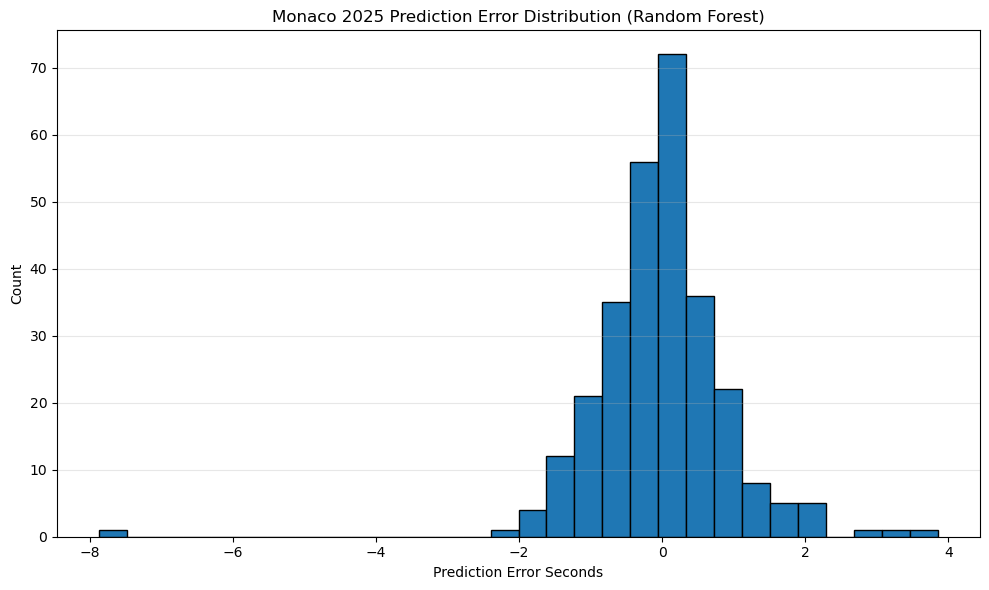

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    prediction_results["PredictionErrorSeconds"],
    bins=30,
    edgecolor="black"
)

plt.title(f"Monaco 2025 Prediction Error Distribution ({best_model_name})")
plt.xlabel("Prediction Error Seconds")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "monaco_2025_prediction_error_distribution.png", dpi=300)
plt.show()

In [20]:
largest_errors = prediction_results.copy()
largest_errors["AbsoluteErrorSeconds"] = largest_errors["PredictionErrorSeconds"].abs()

largest_errors = largest_errors.sort_values("AbsoluteErrorSeconds", ascending=False)

largest_errors.head(15)

,Driver,Team,Compound,LapNumber,TyreLife,TyreLifeSquared,Stint,Position,TrackStatus,IsPitLap,...,StintProgress,DriverMedianPace,TeamMedianPace,PreviousLapTime,Rolling3LapAvg,Rolling5LapAvg,ActualLapTimeSeconds,PredictedLapTimeSeconds,PredictionErrorSeconds,AbsoluteErrorSeconds
259,BOR,Kick Sauber,HARD,4.0,3.0,9.0,2.0,20.0,671,0,...,0.120000,78.2140,78.3335,109.362,109.554000,109.5540,83.609,91.481107,-7.872107,7.872107
210,BEA,Haas F1 Team,MEDIUM,29.0,12.0,144.0,3.0,17.0,1,0,...,0.203390,78.3690,77.6480,77.126,77.386667,77.5170,81.565,77.710053,3.854947,3.854947
968,PIA,McLaren,HARD,23.0,3.0,9.0,2.0,4.0,1,0,...,0.107143,75.1130,75.1900,73.818,81.850667,79.1070,77.790,74.511930,3.278070,3.278070
32,ALB,Williams,MEDIUM,34.0,10.0,100.0,2.0,10.0,1,0,...,0.250000,77.0860,77.0750,82.236,84.033333,81.1914,80.232,77.364073,2.867927,2.867927
614,HUL,Kick Sauber,SOFT,50.0,6.0,36.0,3.0,18.0,1,0,...,0.187500,78.5080,78.3335,78.676,76.715000,77.0244,76.425,78.697143,-2.272143,2.272143
198,BEA,Haas F1 Team,HARD,17.0,16.0,256.0,2.0,19.0,1,1,...,1.000000,78.3690,77.6480,80.638,79.406000,79.4598,97.866,95.615863,2.250137,2.250137
626,HUL,Kick Sauber,SOFT,62.0,18.0,324.0,3.0,18.0,1,0,...,0.562500,78.5080,78.3335,79.041,78.945333,78.6878,81.565,79.338980,2.226020,2.226020
31,ALB,Williams,MEDIUM,33.0,9.0,81.0,2.0,10.0,1,1,...,0.125000,77.0860,77.0750,92.994,82.250667,80.0844,82.236,80.044333,2.191667,2.191667
1156,SAI,Williams,MEDIUM,59.0,14.0,196.0,3.0,9.0,1,0,...,0.260870,77.0640,77.0750,76.214,75.278000,76.3868,77.954,75.877747,2.076253,2.076253
67,ALB,Williams,HARD,69.0,29.0,841.0,3.0,9.0,1,0,...,0.805556,77.0860,77.0750,74.885,74.894333,75.2134,76.790,74.883983,1.906017,1.906017


## Feature Importance

Tree-based models can show which features were most important for prediction.

For Linear Regression, feature importance is less direct because coefficients are affected by encoding and scaling.

In [21]:
def get_feature_names_from_preprocessor(preprocessor):
    """
    Gets feature names after ColumnTransformer preprocessing.
    """
    feature_names = []
    
    cat_transformer = preprocessor.named_transformers_["cat"]
    cat_feature_names = cat_transformer.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)
    
    feature_names.extend(numeric_features)
    
    return feature_names

In [22]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    fitted_model = best_pipeline.named_steps["model"]
    
    feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)
    importances = fitted_model.feature_importances_
    
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
    
    feature_importance_path = METRICS_DIR / "monaco_2025_feature_importance.csv"
    feature_importance.to_csv(feature_importance_path, index=False)
    
    print("Saved feature importance:")
    print(feature_importance_path)
    
    feature_importance.head(20)
else:
    print(f"Feature importance chart skipped because best model is {best_model_name}.")

Saved feature importance:
../outputs/metrics/monaco_2025_feature_importance.csv


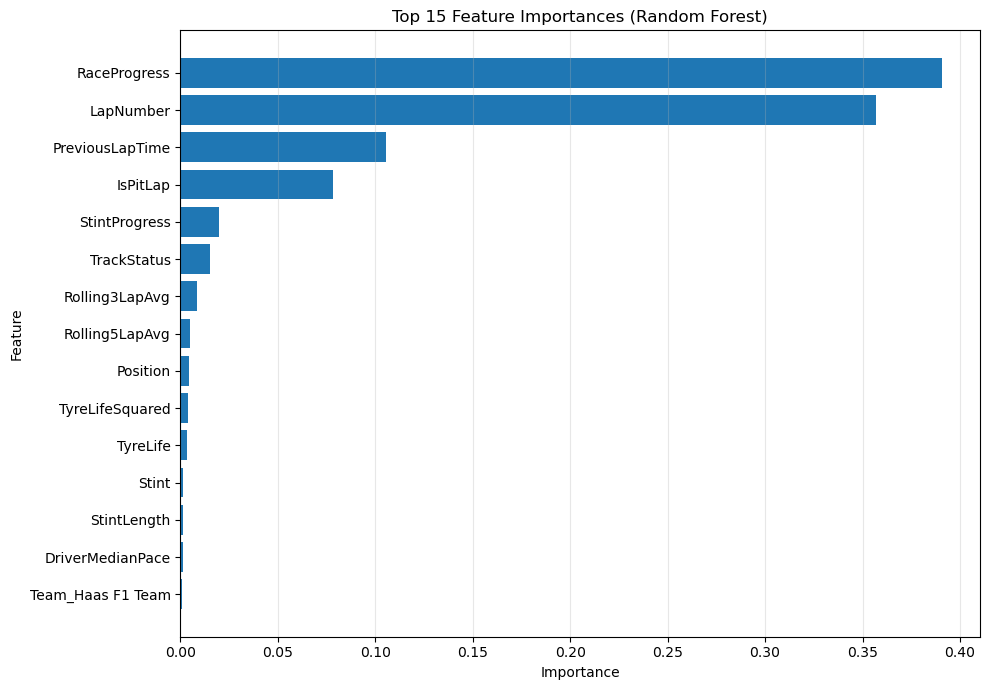

In [23]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    top_features = feature_importance.head(15).sort_values("Importance")
    
    plt.figure(figsize=(10, 7))
    
    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )
    
    plt.title(f"Top 15 Feature Importances ({best_model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(FIGURES_DIR / "monaco_2025_feature_importance.png", dpi=300)
    plt.show()

## Manual Prediction Test

This section tests the model on one example lap from the test dataset.

In [24]:
sample_row = X_test.iloc[[0]].copy()

sample_prediction = best_pipeline.predict(sample_row)[0]
actual_value = y_test.iloc[0]

print("Sample input:")
display(sample_row)

print("\nActual lap time:", actual_value)
print("Predicted lap time:", sample_prediction)
print("Error:", actual_value - sample_prediction)

Sample input:


,Driver,Team,Compound,LapNumber,TyreLife,TyreLifeSquared,Stint,Position,TrackStatus,IsPitLap,IsGreenFlag,RaceProgress,StintLength,StintProgress,DriverMedianPace,TeamMedianPace,PreviousLapTime,Rolling3LapAvg,Rolling5LapAvg
1092,RUS,Mercedes,HARD,70.0,2.0,4.0,3.0,11.0,1,0,1,0.897436,8.0,0.25,78.479,78.865,78.119,80.893,78.1754



Actual lap time: 74.303
Predicted lap time: 75.35132
Error: -1.048320000000004


## Phase 5 Summary

In this notebook, we trained and compared machine learning models to predict Monaco 2025 lap times.

The target variable was `LapTimeSeconds`.

The models tested were:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The best-performing model was the Random Forest Regressor, with an MAE of approximately 0.62 seconds. This means the model predicted lap times within about 0.62 seconds on average on the test set.

The Random Forest and Gradient Boosting models performed much better than Linear Regression, suggesting that lap-time prediction is a non-linear problem. Race progress, lap number, previous lap time, pit-lap status, stint progress, and track status were among the most important features.

The actual vs predicted chart showed that the model performed well for normal racing laps, especially laps in the 74–82 second range. The prediction error distribution was centered close to zero, meaning the model did not strongly overpredict or underpredict lap times overall. However, a few larger errors remained, mostly likely due to unusual race situations such as abnormal track status, traffic effects, pit context, or outlier laps.

This first model should be interpreted as a live-race lap-time prediction model because it uses previous lap and rolling pace features. It is not yet a true pre-race strategy model.

Because this phase used a random train/test split within a single race, the results are useful for a first learning version but may be optimistic. In future phases, when more races are added, the model should be tested on unseen races to better evaluate generalization.

The trained model, prediction results, model comparison metrics, and feature importance outputs were saved for later use in the Streamlit dashboard.

In the next phase, we will build an interactive Streamlit dashboard that allows users to explore Monaco 2025 race pace, tyre degradation, and lap-time predictions.